Initial load for function 1.

In [1]:
# Import the necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

[3 7 0 4]
0.8119332021139528
0.7844734007702444


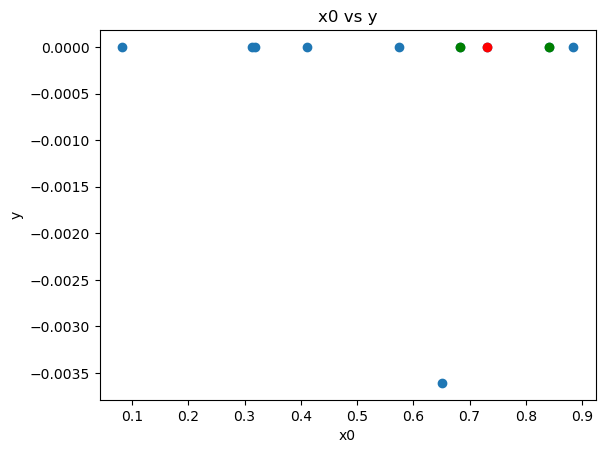

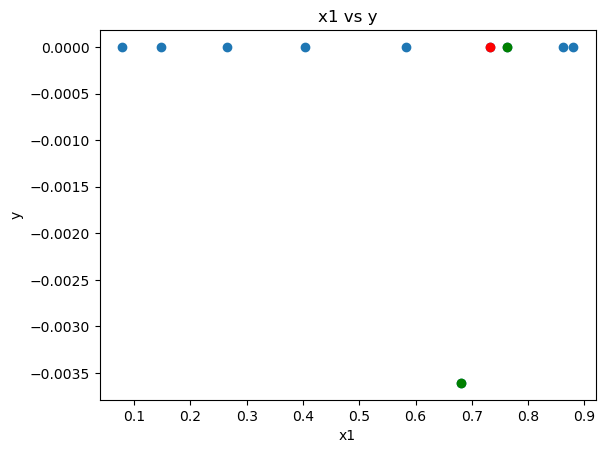

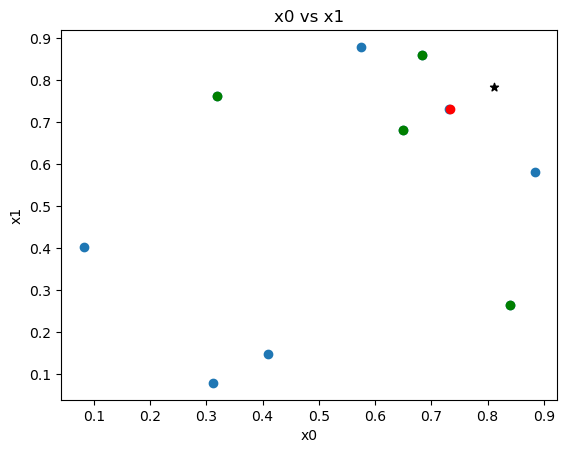

In [49]:
#Load initial data
x = np.load("initial_data/function_1/initial_inputs.npy")
y = np.transpose(np.load("initial_data/function_1/initial_outputs.npy"))

#there is a very low value that we want to supress so we'll manually remove it for now

#inliers = y > -0.0001;
#x = x[inliers, :];
#y = y[inliers];


#rank the data so we can see what points we are interested in I want to highlight max and two neighbours
x0_order = np.flip(np.argsort(x[:,:1],0)).flatten();
x1_order = np.flip(np.argsort(x[:,1:2],0)).flatten();
y_order = np.flip(np.argsort(y,0)).flatten();

max_y_ind = y_order[0];
min_y_ind = y_order[-1];

#calc vector between min and max position:

dx0 = -(x[max_y_ind,0]-x[min_y_ind,0]);
dx1 = -(x[max_y_ind,-1]-x[min_y_ind,-1]);

mag = np.sqrt(dx0**2+dx1**2);

np_x0 = x[max_y_ind,0]-dx0;
np_x1 = x[max_y_ind,-1]-dx1;


#next find nearest neighbours
max_y_in_x0 = np.argwhere(x0_order == max_y_ind);
lower_x0_ind = x0_order[max_y_in_x0-1];
upper_x0_ind = x0_order[max_y_in_x0+1];

max_y_in_x1 = np.argwhere(x1_order == max_y_ind);
lower_x1_ind = x1_order[max_y_in_x1-1];
upper_x1_ind = x1_order[max_y_in_x1+1];


# add neighbours into array
neighbours_ind = np.array([lower_x0_ind, upper_x0_ind, lower_x1_ind, upper_x1_ind]).flatten()
print(neighbours_ind)

#np_x0 = np.mean(x[neighbours_ind, :1]);
#np_x1 = np.mean(x[neighbours_ind, 1:2]);
print(np_x0)
print(np_x1)


#look at data.
plt.scatter(x[:,:1], y)
plt.scatter(x[max_y_ind,:1], y[max_y_ind],c='red')
plt.scatter(x[lower_x0_ind,:1], y[lower_x0_ind],c='green')
plt.scatter(x[upper_x0_ind,:1], y[upper_x0_ind],c='green')
plt.title("x0 vs y")
plt.xlabel("x0")
plt.ylabel("y")
plt.show()

plt.scatter(x[:,1:2], y)
plt.scatter(x[max_y_ind,1:2], y[max_y_ind],c='red')
plt.scatter(x[lower_x1_ind,1:2], y[lower_x1_ind],c='green')
plt.scatter(x[upper_x1_ind,1:2], y[upper_x1_ind],c='green')
plt.title("x1 vs y")
plt.xlabel("x1")
plt.ylabel("y")
plt.show()

plt.scatter(x[:,:1], x[:,1:2])
plt.scatter(x[max_y_ind,1], x[max_y_ind,1:2],c='red')
plt.scatter(x[lower_x0_ind,:1], x[lower_x0_ind, 1:2],c='green')
plt.scatter(x[upper_x0_ind,:1], x[upper_x0_ind, 1:2],c='green')
plt.scatter(x[lower_x1_ind,:1], x[lower_x1_ind, 1:2],c='green')
plt.scatter(x[upper_x1_ind,:1], x[upper_x1_ind, 1:2],c='green')
plt.scatter(np_x0, np_x1,c='black', marker='*')
plt.title("x0 vs x1")
plt.xlabel("x0")
plt.ylabel("x1")
plt.show()